# CONUS modelling v2: log-target workflow

This notebook is a streamlined modelling pass for the CONUS outage recovery dataset. Models are trained on `log1p(t90)`, but all reported predictions, metrics, tables, and figures are back-transformed to hours using `expm1`.

Model classes included:

- Mean baseline
- Multiple linear regression (MLR)
- Random Forest (RF)
- XGBoost (XGB)

The main validation path is leave-one-storm-out (LOSO), so each held-out fold is an unseen storm.


In [1]:
# --- Imports and notebook settings ---

from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import LeaveOneGroupOut, ParameterGrid
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

try:
    from xgboost import XGBRegressor
    HAS_XGBOOST = True
except ImportError:
    HAS_XGBOOST = False
    XGBRegressor = None

warnings.filterwarnings("ignore", category=UserWarning)
plt.style.use("default")

RANDOM_STATE = 42
RUN_TUNING = True
MAX_XGB_CANDIDATES = 48

ROOT = Path(r"C:\Users\teaching\Downloads\outage-recovery-forecasting")
DATA_DIR = ROOT / "data_transients"
FIG_DIR = ROOT / "python_scripts" / "figures_conus_v2"
FIG_DIR.mkdir(parents=True, exist_ok=True)

MASTER_CANDIDATES = [
    DATA_DIR / "event_level_dataset_conus_modeling_valid.parquet",
    DATA_DIR / "event_level_dataset_conus_master_final.parquet",
    DATA_DIR / "event_level_dataset_conus_master_with_gdp.parquet",
]

print("Figure directory:", FIG_DIR)


Figure directory: C:\Users\teaching\Downloads\outage-recovery-forecasting\python_scripts\figures_conus_v2


In [2]:
# --- Load and prepare modelling table ---

master_path = next((p for p in MASTER_CANDIDATES if p.exists()), None)
if master_path is None:
    raise FileNotFoundError("No CONUS modelling/master parquet found in expected locations.")

if master_path.suffix.lower() == ".parquet":
    event_df = pd.read_parquet(master_path)
else:
    event_df = pd.read_csv(master_path)

event_df["CountyFIPS"] = event_df["CountyFIPS"].astype(str).str.zfill(5)
event_df["event_start"] = pd.to_datetime(event_df["event_start"], errors="coerce")

if "t90" not in event_df.columns and "t90_lastcross" in event_df.columns:
    event_df["t90"] = event_df["t90_lastcross"]

event_df = event_df.dropna(subset=["t90", "storm"]).copy()
event_df = event_df[event_df["t90"] >= 0].copy()
event_df["t90_log"] = np.log1p(event_df["t90"].astype(float))
event_df = event_df.sort_values(["storm", "CountyFIPS", "event_start"]).reset_index(drop=True)

print("Using master file:", master_path)
print("Rows:", len(event_df))
print("Storms:", event_df["storm"].nunique())
print("Counties:", event_df["CountyFIPS"].nunique())
print("t90 hours summary:")
print(event_df["t90"].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]).to_string())


Using master file: C:\Users\teaching\Downloads\outage-recovery-forecasting\data_transients\event_level_dataset_conus_modeling_valid.parquet
Rows: 913
Storms: 28
Counties: 560
t90 hours summary:
count    913.000000
mean      97.122476
std      125.796173
min        1.885185
10%       19.527852
25%       30.337361
50%       56.119162
75%      101.339472
90%      211.256566
max      680.559693


In [3]:
# --- Feature set: main pre-event model uses only the 9 basic predictors ---

PRE_EVENT_FEATURES = [
    "max_gust",
    "mean_gust_7d",
    "total_precip_7d",
    "pressure_min_7d",
    "county_pop",
    "min_dist_to_storm_km",
    "storm_max_wind_near_conus_mps",
    "county_gdp_real_2017_dollars",
    "county_gdp_real_2017_per_capita",
]

# Optional conditional comparison used only in the final section of the notebook.
PEAK_OUTAGE_FEATURE = "peak_outage_clean"

available_pre_event = [c for c in PRE_EVENT_FEATURES if c in event_df.columns]
missing_pre_event = [c for c in PRE_EVENT_FEATURES if c not in event_df.columns]

if missing_pre_event:
    raise KeyError(f"Missing expected pre-event features: {missing_pre_event}")

FEATURE_SETS = {"pre_event": available_pre_event}

print("Main feature set:")
print(f"  pre_event: {len(available_pre_event)} features")
print("   ", available_pre_event)

if PEAK_OUTAGE_FEATURE in event_df.columns:
    print(f"\nPeak-outage comparison is available using: {PEAK_OUTAGE_FEATURE}")
else:
    print(f"\nPeak-outage comparison unavailable: {PEAK_OUTAGE_FEATURE} not found in event_df")


Main feature set:
  pre_event: 9 features
    ['max_gust', 'mean_gust_7d', 'total_precip_7d', 'pressure_min_7d', 'county_pop', 'min_dist_to_storm_km', 'storm_max_wind_near_conus_mps', 'county_gdp_real_2017_dollars', 'county_gdp_real_2017_per_capita']

Peak-outage comparison is available using: peak_outage_clean


In [4]:
# --- Evaluation helpers: train on log(t90), report in hours ---

logo = LeaveOneGroupOut()


def backtransform_log_predictions(y_pred_log):
    """Convert model output from log1p(t90) to hours and clip impossible negatives."""
    return np.clip(np.expm1(np.asarray(y_pred_log, dtype=float)), 0, None)


def compute_hour_metrics(y_true_hours, y_pred_hours):
    y_true_hours = np.asarray(y_true_hours, dtype=float)
    y_pred_hours = np.asarray(y_pred_hours, dtype=float)
    return {
        "MAE_hours": mean_absolute_error(y_true_hours, y_pred_hours),
        "RMSE_hours": np.sqrt(mean_squared_error(y_true_hours, y_pred_hours)),
        "R2_hours": r2_score(y_true_hours, y_pred_hours),
        "median_AE_hours": np.median(np.abs(y_true_hours - y_pred_hours)),
        "nMAE_vs_mean_t90": mean_absolute_error(y_true_hours, y_pred_hours) / np.mean(y_true_hours),
        "nMAE_vs_median_t90": mean_absolute_error(y_true_hours, y_pred_hours) / np.median(y_true_hours),
    }


def evaluate_loso_log_model(model, X, y_hours, groups, model_name="model", feature_set="pre_event"):
    y_log = np.log1p(y_hours.astype(float))
    preds_log = np.full(len(y_hours), np.nan)
    fold_rows = []

    for fold_i, (train_idx, test_idx) in enumerate(logo.split(X, y_log, groups), start=1):
        fitted = clone(model)
        fitted.fit(X.iloc[train_idx], y_log.iloc[train_idx])
        pred_log = fitted.predict(X.iloc[test_idx])
        pred_hours = backtransform_log_predictions(pred_log)
        true_hours = y_hours.iloc[test_idx].to_numpy(dtype=float)
        preds_log[test_idx] = pred_log

        row = {
            "model": model_name,
            "feature_set": feature_set,
            "fold": fold_i,
            "storm": groups.iloc[test_idx].iloc[0],
            "n": len(test_idx),
        }
        row.update(compute_hour_metrics(true_hours, pred_hours))
        fold_rows.append(row)

    preds_hours = backtransform_log_predictions(preds_log)
    global_metrics = compute_hour_metrics(y_hours, preds_hours)
    global_metrics.update({
        "model": model_name,
        "feature_set": feature_set,
        "n": len(y_hours),
        "n_storms": groups.nunique(),
    })

    pred_df = event_df.loc[X.index, ["storm", "CountyFIPS", "event_start", "t90"]].copy()
    pred_df["model"] = model_name
    pred_df["feature_set"] = feature_set
    pred_df["pred_log"] = preds_log
    pred_df["pred_hours"] = preds_hours
    pred_df["abs_error_hours"] = np.abs(pred_df["t90"] - pred_df["pred_hours"])

    return pred_df, pd.DataFrame(fold_rows), global_metrics


def tune_loso_log_model(model_factory, param_grid, X, y_hours, groups, model_name, feature_set, max_candidates=None, random_state=RANDOM_STATE):
    candidates = list(ParameterGrid(param_grid))
    if max_candidates is not None and len(candidates) > max_candidates:
        rng = np.random.default_rng(random_state)
        idx = rng.choice(len(candidates), size=max_candidates, replace=False)
        candidates = [candidates[i] for i in idx]

    rows = []
    best = {"MAE_hours": np.inf, "params": None, "pred_df": None, "fold_df": None}

    print(f"Tuning {model_name} on {feature_set}: {len(candidates)} candidates")
    for i, params in enumerate(candidates, start=1):
        model = model_factory(params)
        pred_df, fold_df, metrics = evaluate_loso_log_model(
            model, X, y_hours, groups, model_name=model_name, feature_set=feature_set
        )
        rows.append({**params, **metrics})

        if metrics["MAE_hours"] < best["MAE_hours"]:
            best = {
                "MAE_hours": metrics["MAE_hours"],
                "params": params.copy(),
                "pred_df": pred_df.copy(),
                "fold_df": fold_df.copy(),
            }
        print(f"  {i:>3}/{len(candidates)} best MAE so far: {best['MAE_hours']:.2f} h", end="\r")

    print()
    search_df = pd.DataFrame(rows).sort_values("MAE_hours").reset_index(drop=True)
    return search_df, best


def summarize_results(metrics_rows):
    cols = ["feature_set", "model", "MAE_hours", "RMSE_hours", "median_AE_hours", "R2_hours", "nMAE_vs_mean_t90", "nMAE_vs_median_t90", "n", "n_storms"]
    return pd.DataFrame(metrics_rows)[cols].sort_values(["feature_set", "MAE_hours"]).reset_index(drop=True)


def metric_subset(row):
    cols = ["model", "feature_set", "n", "n_storms", "MAE_hours", "RMSE_hours", "R2_hours", "median_AE_hours", "nMAE_vs_mean_t90", "nMAE_vs_median_t90"]
    return row[cols].to_dict()


In [5]:
# --- Model factories ---


def numeric_preprocess(features, scale=False):
    steps = [("imputer", SimpleImputer(strategy="median"))]
    if scale:
        steps.append(("scaler", StandardScaler()))
    return ColumnTransformer([("num", Pipeline(steps), features)])


def make_mean_model(features):
    return Pipeline([
        ("preprocess", numeric_preprocess(features, scale=False)),
        ("model", DummyRegressor(strategy="mean")),
    ])


def make_mlr_model(features):
    return Pipeline([
        ("preprocess", numeric_preprocess(features, scale=True)),
        ("model", LinearRegression()),
    ])


def make_rf_model(features, params):
    return Pipeline([
        ("preprocess", numeric_preprocess(features, scale=False)),
        ("model", RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1, **params)),
    ])


def make_xgb_model(features, params):
    if not HAS_XGBOOST:
        raise ImportError("xgboost is not installed in this environment.")
    return Pipeline([
        ("preprocess", numeric_preprocess(features, scale=False)),
        ("model", XGBRegressor(objective="reg:squarederror", random_state=RANDOM_STATE, n_jobs=-1, **params)),
    ])


In [6]:
# --- Hyperparameter spaces ---

RF_GRID = {
    "n_estimators": [200, 400],
    "max_depth": [10, 20, 30, None],
    "min_samples_leaf": [1, 2, 3, 5],
    "max_features": [0.1, 0.3, 0.5, 1.0],
}

XGB_GRID = {
    "n_estimators": [100, 200, 300, 400],
    "learning_rate": [0.03, 0.05, 0.08, 0.1],
    "max_depth": [2, 3, 4, 5],
    "min_child_weight": [1, 2, 3],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "gamma": [0.0, 0.5, 1.0],
    "reg_alpha": [0.0, 0.5, 1.0],
    "reg_lambda": [1.0, 5.0, 10.0],
}

print("RF candidates:", len(list(ParameterGrid(RF_GRID))))
print("XGB candidates before sampling:", len(list(ParameterGrid(XGB_GRID))))


RF candidates: 128
XGB candidates before sampling: 31104


In [7]:
# --- Run LOSO evaluation and tuning ---

all_metrics = []
all_predictions = []
all_folds = []
search_tables = {}
best_params = {}

for feature_set_name, features in FEATURE_SETS.items():
    X = event_df[features].copy()
    y = event_df["t90"].astype(float).copy()
    groups = event_df["storm"].copy()

    print("=" * 80)
    print(f"Feature set: {feature_set_name} ({len(features)} features)")
    print("Missing values by feature:")
    print(X.isna().sum().sort_values(ascending=False).to_string())

    base_models = {
        "Mean": make_mean_model(features),
        "MLR": make_mlr_model(features),
    }
    for model_name, model in base_models.items():
        pred_df, fold_df, metrics = evaluate_loso_log_model(model, X, y, groups, model_name=model_name, feature_set=feature_set_name)
        all_metrics.append(metrics)
        all_predictions.append(pred_df)
        all_folds.append(fold_df)
        print(f"{model_name}: MAE={metrics['MAE_hours']:.2f} h, RMSE={metrics['RMSE_hours']:.2f} h")

    if RUN_TUNING:
        rf_search, rf_best = tune_loso_log_model(
            lambda p: make_rf_model(features, p), RF_GRID, X, y, groups,
            model_name="RF", feature_set=feature_set_name
        )
        search_tables[(feature_set_name, "RF")] = rf_search
        best_params[(feature_set_name, "RF")] = rf_best["params"]
        all_metrics.append(metric_subset(rf_search.iloc[0]))
        all_predictions.append(rf_best["pred_df"])
        all_folds.append(rf_best["fold_df"])
        print("Best RF params:", rf_best["params"])

        if HAS_XGBOOST:
            xgb_search, xgb_best = tune_loso_log_model(
                lambda p: make_xgb_model(features, p), XGB_GRID, X, y, groups,
                model_name="XGB", feature_set=feature_set_name,
                max_candidates=MAX_XGB_CANDIDATES
            )
            search_tables[(feature_set_name, "XGB")] = xgb_search
            best_params[(feature_set_name, "XGB")] = xgb_best["params"]
            all_metrics.append(metric_subset(xgb_search.iloc[0]))
            all_predictions.append(xgb_best["pred_df"])
            all_folds.append(xgb_best["fold_df"])
            print("Best XGB params:", xgb_best["params"])
        else:
            print("Skipping XGB because xgboost is not installed.")

results_summary = summarize_results(all_metrics)
results_summary


Feature set: pre_event (9 features)
Missing values by feature:
county_gdp_real_2017_dollars       18
county_gdp_real_2017_per_capita    18
max_gust                            0
mean_gust_7d                        0
total_precip_7d                     0
county_pop                          0
pressure_min_7d                     0
storm_max_wind_near_conus_mps       0
min_dist_to_storm_km                0
Mean: MAE=66.54 h, RMSE=131.98 h
MLR: MAE=58.01 h, RMSE=121.13 h
Tuning RF on pre_event: 128 candidates


c:\Users\teaching\Downloads\outage-recovery-forecasting\.venv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\teaching\Downloads\outage-recovery-forecasting\.venv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\teaching\Downloads\outage-recovery-forecasting\.venv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warn

c:\Users\teaching\Downloads\outage-recovery-forecasting\.venv\Lib\site-packages\sklearn\metrics\_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
c:\Users\teaching\Downloads\outage-recovery-forecasting\.venv\Lib\site-packages\sklearn\metrics\_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
c:\Users\teaching\Downloads\outage-recovery-forecasting\.venv\Lib\site-packages\sklearn\metrics\_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
c:\Users\teaching\Downloads\outage-recovery-forecasting\.venv\Lib\site-packages\sklearn\metrics\_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


c:\Users\teaching\Downloads\outage-recovery-forecasting\.venv\Lib\site-packages\sklearn\metrics\_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
c:\Users\teaching\Downloads\outage-recovery-forecasting\.venv\Lib\site-packages\sklearn\metrics\_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
c:\Users\teaching\Downloads\outage-recovery-forecasting\.venv\Lib\site-packages\sklearn\metrics\_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
c:\Users\teaching\Downloads\outage-recovery-forecasting\.venv\Lib\site-packages\sklearn\metrics\_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


c:\Users\teaching\Downloads\outage-recovery-forecasting\.venv\Lib\site-packages\sklearn\metrics\_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
c:\Users\teaching\Downloads\outage-recovery-forecasting\.venv\Lib\site-packages\sklearn\metrics\_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
c:\Users\teaching\Downloads\outage-recovery-forecasting\.venv\Lib\site-packages\sklearn\metrics\_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
c:\Users\teaching\Downloads\outage-recovery-forecasting\.venv\Lib\site-packages\sklearn\metrics\_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


...

c:\Users\teaching\Downloads\outage-recovery-forecasting\.venv\Lib\site-packages\sklearn\metrics\_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
c:\Users\teaching\Downloads\outage-recovery-forecasting\.venv\Lib\site-packages\sklearn\metrics\_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
c:\Users\teaching\Downloads\outage-recovery-forecasting\.venv\Lib\site-packages\sklearn\metrics\_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
c:\Users\teaching\Downloads\outage-recovery-forecasting\.venv\Lib\site-packages\sklearn\metrics\_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


c:\Users\teaching\Downloads\outage-recovery-forecasting\.venv\Lib\site-packages\sklearn\metrics\_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
c:\Users\teaching\Downloads\outage-recovery-forecasting\.venv\Lib\site-packages\sklearn\metrics\_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
c:\Users\teaching\Downloads\outage-recovery-forecasting\.venv\Lib\site-packages\sklearn\metrics\_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
c:\Users\teaching\Downloads\outage-recovery-forecasting\.venv\Lib\site-packages\sklearn\metrics\_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


c:\Users\teaching\Downloads\outage-recovery-forecasting\.venv\Lib\site-packages\sklearn\metrics\_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
c:\Users\teaching\Downloads\outage-recovery-forecasting\.venv\Lib\site-packages\sklearn\metrics\_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
c:\Users\teaching\Downloads\outage-recovery-forecasting\.venv\Lib\site-packages\sklearn\metrics\_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
c:\Users\teaching\Downloads\outage-recovery-forecasting\.venv\Lib\site-packages\sklearn\metrics\_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


   48/48 best MAE so far: 34.65 h
Best XGB params: {'colsample_bytree': 0.8, 'gamma': 0.0, 'learning_rate': 0.1, 'max_depth': 5, 'min_child_weight': 1, 'n_estimators': 200, 'reg_alpha': 0.0, 'reg_lambda': 10.0, 'subsample': 1.0}


,feature_set,model,MAE_hours,RMSE_hours,median_AE_hours,R2_hours,nMAE_vs_mean_t90,nMAE_vs_median_t90,n,n_storms
0,pre_event,RF,31.803428,61.943354,15.975266,0.757266,0.327457,0.566712,913,28
1,pre_event,XGB,34.648178,64.646020,16.475400,0.735622,0.356747,0.617404,913,28
2,pre_event,MLR,58.005067,121.125891,22.129482,0.071857,0.597236,1.033605,913,28
3,pre_event,Mean,66.544857,131.981520,31.285888,-0.101964,0.685164,1.185778,913,28


In [8]:
# --- Save result tables ---

predictions_df = pd.concat(all_predictions, ignore_index=True) if all_predictions else pd.DataFrame()
folds_df = pd.concat(all_folds, ignore_index=True) if all_folds else pd.DataFrame()

results_path = DATA_DIR / "conus_v2_log_target_results_summary.csv"
pred_path = DATA_DIR / "conus_v2_log_target_loso_predictions.csv"
fold_path = DATA_DIR / "conus_v2_log_target_loso_folds.csv"
params_path = DATA_DIR / "conus_v2_log_target_best_params.json"

results_summary.to_csv(results_path, index=False)
predictions_df.to_csv(pred_path, index=False)
folds_df.to_csv(fold_path, index=False)

serializable_params = {f"{fs}__{model}": params for (fs, model), params in best_params.items()}
with open(params_path, "w") as f:
    json.dump(serializable_params, f, indent=2)

for (fs, model), table in search_tables.items():
    safe_model = model.lower().replace(" ", "_").replace("/", "_")
    table.to_csv(DATA_DIR / f"conus_v2_search_{fs}_{safe_model}.csv", index=False)

print("Saved:")
print(results_path)
print(pred_path)
print(fold_path)
print(params_path)


Saved:
C:\Users\teaching\Downloads\outage-recovery-forecasting\data_transients\conus_v2_log_target_results_summary.csv
C:\Users\teaching\Downloads\outage-recovery-forecasting\data_transients\conus_v2_log_target_loso_predictions.csv
C:\Users\teaching\Downloads\outage-recovery-forecasting\data_transients\conus_v2_log_target_loso_folds.csv
C:\Users\teaching\Downloads\outage-recovery-forecasting\data_transients\conus_v2_log_target_best_params.json


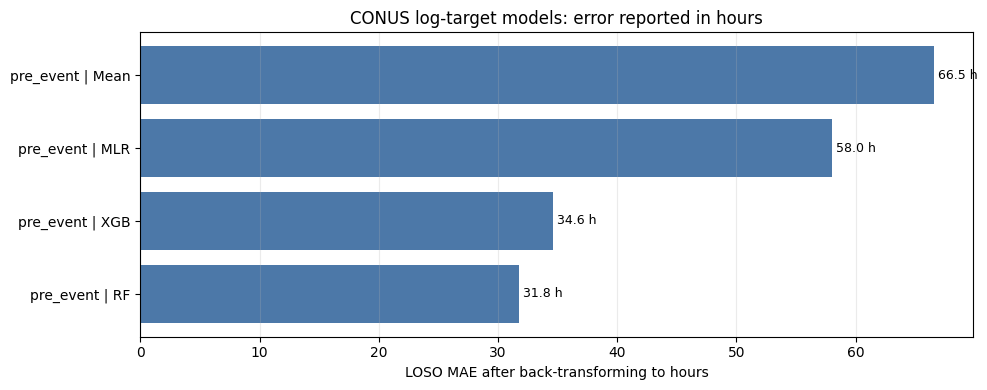

In [9]:
# --- Plot: model comparison in hours ---

plot_df = results_summary.copy()
plot_df["label"] = plot_df["feature_set"] + " | " + plot_df["model"]
plot_df = plot_df.sort_values("MAE_hours", ascending=True)

fig, ax = plt.subplots(figsize=(10, max(4, 0.45 * len(plot_df))))
ax.barh(plot_df["label"], plot_df["MAE_hours"], color="#4c78a8")
ax.set_xlabel("LOSO MAE after back-transforming to hours")
ax.set_ylabel("")
ax.set_title("CONUS log-target models: error reported in hours")
ax.grid(axis="x", alpha=0.25)
for i, value in enumerate(plot_df["MAE_hours"]):
    ax.text(value, i, f" {value:.1f} h", va="center", fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / "conus_v2_model_comparison_mae_hours.png", dpi=200)
plt.show()


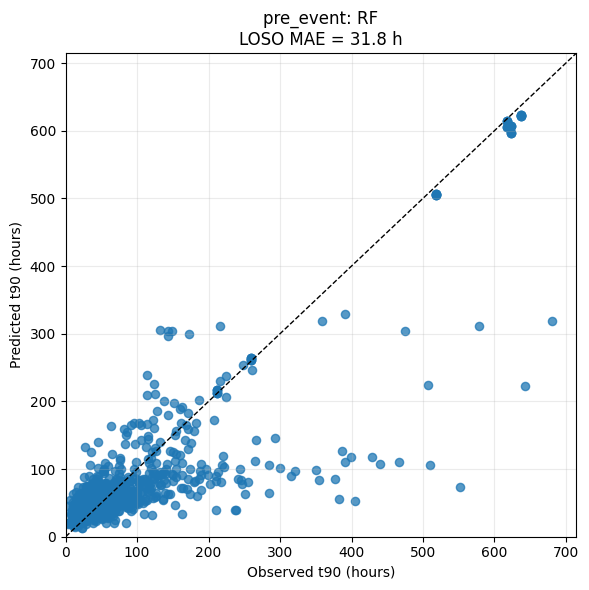

In [10]:
# --- Plot: observed vs predicted for the best model in each feature set ---

best_by_feature = (
    results_summary.sort_values("MAE_hours")
    .groupby("feature_set", as_index=False)
    .first()[["feature_set", "model", "MAE_hours"]]
)

for _, row in best_by_feature.iterrows():
    fs = row["feature_set"]
    model = row["model"]
    dfp = predictions_df[(predictions_df["feature_set"] == fs) & (predictions_df["model"] == model)].copy()
    if dfp.empty:
        continue

    lim_max = max(dfp["t90"].max(), dfp["pred_hours"].max()) * 1.05
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(dfp["t90"], dfp["pred_hours"], alpha=0.75, s=35)
    ax.plot([0, lim_max], [0, lim_max], color="black", lw=1, linestyle="--")
    ax.set_xlim(0, lim_max)
    ax.set_ylim(0, lim_max)
    ax.set_xlabel("Observed t90 (hours)")
    ax.set_ylabel("Predicted t90 (hours)")
    ax.set_title(f"{fs}: {model}\nLOSO MAE = {row['MAE_hours']:.1f} h")
    ax.grid(alpha=0.25)
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"conus_v2_obs_vs_pred_{fs}.png", dpi=200)
    plt.show()


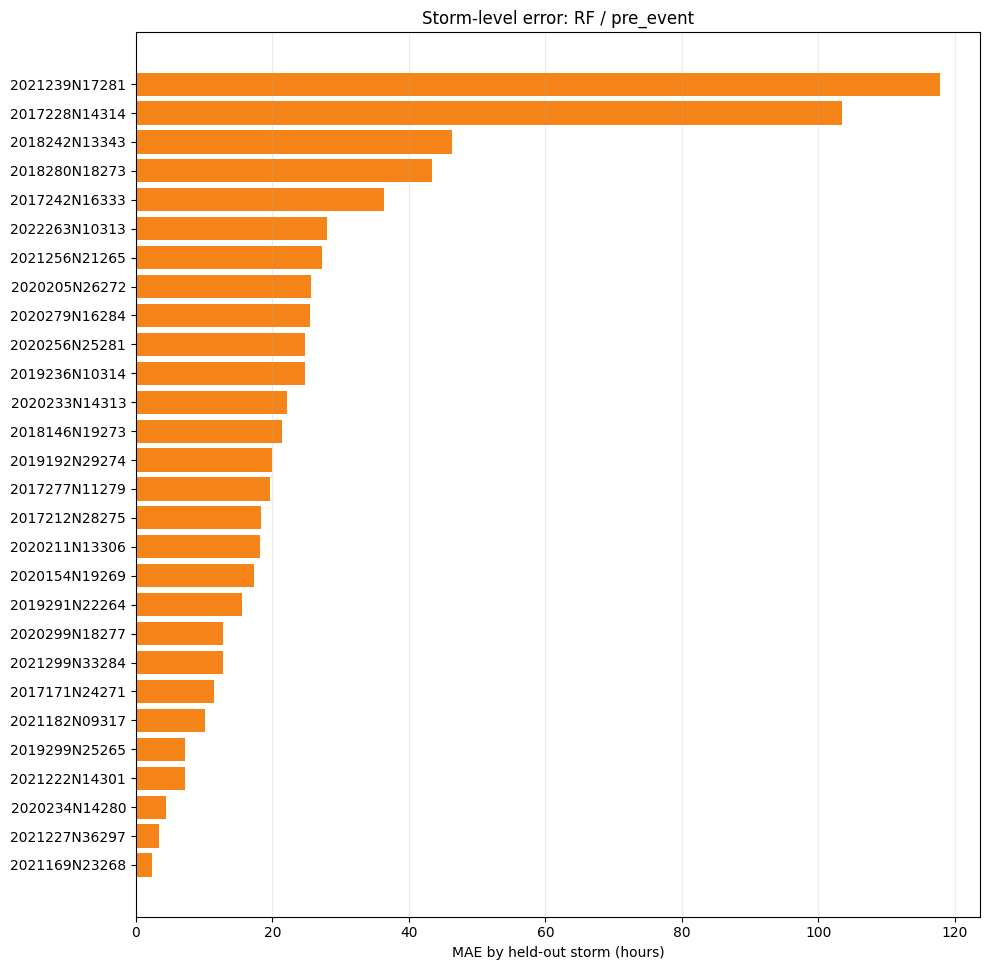

,storm,n,MAE_hours,median_t90
0,2021239N17281,39,117.795643,164.507620
1,2017228N14314,19,103.398193,138.287075
2,2018242N13343,40,46.276427,102.081737
3,2018280N18273,152,43.432531,51.359846
4,2017242N16333,127,36.383986,84.829661
5,2022263N10313,34,27.935442,35.253403
6,2021256N21265,8,27.282452,50.107094
7,2020205N26272,7,25.693527,44.151735
8,2020279N16284,49,25.458219,63.970561
9,2020256N25281,11,24.797261,69.376300


In [11]:
# --- Plot: error by storm for best pre-event model ---

pre_best = results_summary[results_summary["feature_set"] == "pre_event"].sort_values("MAE_hours").iloc[0]
pre_best_model = pre_best["model"]
pre_best_pred = predictions_df[(predictions_df["feature_set"] == "pre_event") & (predictions_df["model"] == pre_best_model)].copy()

storm_err = (
    pre_best_pred.groupby("storm")
    .agg(n=("t90", "size"), MAE_hours=("abs_error_hours", "mean"), median_t90=("t90", "median"))
    .sort_values("MAE_hours", ascending=False)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, max(4, 0.35 * len(storm_err))))
ax.barh(storm_err["storm"], storm_err["MAE_hours"], color="#f58518")
ax.invert_yaxis()
ax.set_xlabel("MAE by held-out storm (hours)")
ax.set_ylabel("")
ax.set_title(f"Storm-level error: {pre_best_model} / pre_event")
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.savefig(FIG_DIR / "conus_v2_pre_event_error_by_storm.png", dpi=200)
plt.show()

storm_err.head(20)


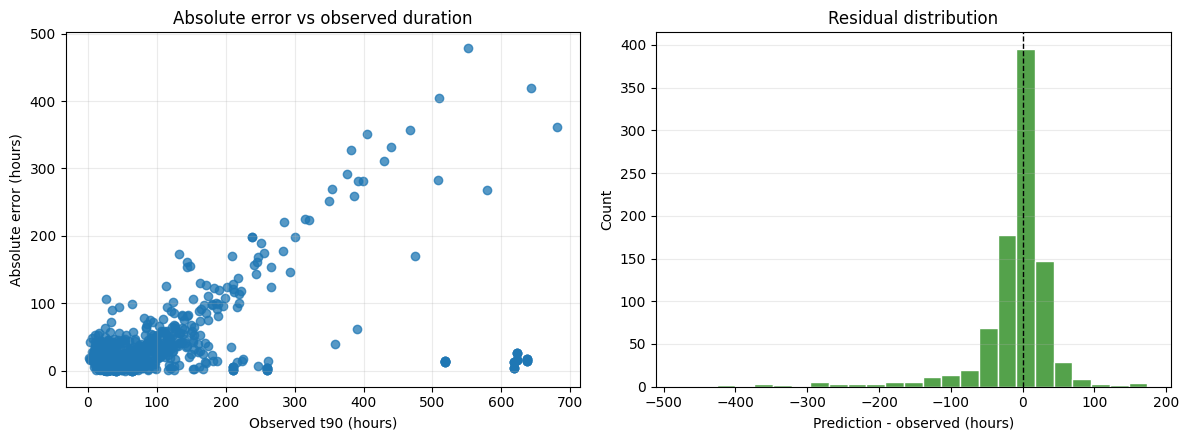

In [12]:
# --- Plot: residual diagnostics for best pre-event model ---

pre_best_pred["residual_hours"] = pre_best_pred["pred_hours"] - pre_best_pred["t90"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].scatter(pre_best_pred["t90"], pre_best_pred["abs_error_hours"], alpha=0.75)
axes[0].set_xlabel("Observed t90 (hours)")
axes[0].set_ylabel("Absolute error (hours)")
axes[0].set_title("Absolute error vs observed duration")
axes[0].grid(alpha=0.25)

axes[1].hist(pre_best_pred["residual_hours"], bins=25, color="#54a24b", edgecolor="white")
axes[1].axvline(0, color="black", linestyle="--", lw=1)
axes[1].set_xlabel("Prediction - observed (hours)")
axes[1].set_ylabel("Count")
axes[1].set_title("Residual distribution")
axes[1].grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.savefig(FIG_DIR / "conus_v2_pre_event_residual_diagnostics.png", dpi=200)
plt.show()


## Peak-outage conditional comparison

The main results above use only the 9 pre-event predictors. This section reruns the same four model classes after adding `peak_outage_clean` as the only conditional predictor. Treat these results as a post-impact/oracle-severity comparison, not as a deployable pre-event forecast.


In [ ]:
# --- Peak-outage conditional comparison: 9 predictors + peak_outage_clean only ---

if PEAK_OUTAGE_FEATURE not in event_df.columns:
    raise KeyError(f"{PEAK_OUTAGE_FEATURE} is not available in event_df.")

PEAK_FEATURES = available_pre_event + [PEAK_OUTAGE_FEATURE]
peak_feature_set_name = "pre_event_plus_peak_outage_clean"

X_peak = event_df[PEAK_FEATURES].copy()
y_peak = event_df["t90"].astype(float).copy()
groups_peak = event_df["storm"].copy()

print(f"Feature set: {peak_feature_set_name} ({len(PEAK_FEATURES)} features)")
print("Features:", PEAK_FEATURES)
print("Missing values by feature:")
print(X_peak.isna().sum().sort_values(ascending=False).to_string())

peak_metrics = []
peak_predictions = []
peak_folds = []
peak_search_tables = {}
peak_best_params = {}

peak_base_models = {
    "Mean": make_mean_model(PEAK_FEATURES),
    "MLR": make_mlr_model(PEAK_FEATURES),
}

for model_name, model in peak_base_models.items():
    pred_df, fold_df, metrics = evaluate_loso_log_model(
        model, X_peak, y_peak, groups_peak,
        model_name=model_name,
        feature_set=peak_feature_set_name,
    )
    peak_metrics.append(metrics)
    peak_predictions.append(pred_df)
    peak_folds.append(fold_df)
    print(f"{model_name}: MAE={metrics['MAE_hours']:.2f} h, RMSE={metrics['RMSE_hours']:.2f} h")

if RUN_TUNING:
    peak_rf_search, peak_rf_best = tune_loso_log_model(
        lambda p: make_rf_model(PEAK_FEATURES, p), RF_GRID, X_peak, y_peak, groups_peak,
        model_name="RF", feature_set=peak_feature_set_name,
    )
    peak_search_tables[(peak_feature_set_name, "RF")] = peak_rf_search
    peak_best_params[(peak_feature_set_name, "RF")] = peak_rf_best["params"]
    peak_metrics.append(metric_subset(peak_rf_search.iloc[0]))
    peak_predictions.append(peak_rf_best["pred_df"])
    peak_folds.append(peak_rf_best["fold_df"])
    print("Best RF params:", peak_rf_best["params"])

    if HAS_XGBOOST:
        peak_xgb_search, peak_xgb_best = tune_loso_log_model(
            lambda p: make_xgb_model(PEAK_FEATURES, p), XGB_GRID, X_peak, y_peak, groups_peak,
            model_name="XGB", feature_set=peak_feature_set_name,
            max_candidates=MAX_XGB_CANDIDATES,
        )
        peak_search_tables[(peak_feature_set_name, "XGB")] = peak_xgb_search
        peak_best_params[(peak_feature_set_name, "XGB")] = peak_xgb_best["params"]
        peak_metrics.append(metric_subset(peak_xgb_search.iloc[0]))
        peak_predictions.append(peak_xgb_best["pred_df"])
        peak_folds.append(peak_xgb_best["fold_df"])
        print("Best XGB params:", peak_xgb_best["params"])
    else:
        print("Skipping XGB because xgboost is not installed.")

peak_results_summary = summarize_results(peak_metrics)
peak_predictions_df = pd.concat(peak_predictions, ignore_index=True) if peak_predictions else pd.DataFrame()
peak_folds_df = pd.concat(peak_folds, ignore_index=True) if peak_folds else pd.DataFrame()

peak_results_summary


Feature set: pre_event_plus_peak_outage_clean (10 features)
Features: ['max_gust', 'mean_gust_7d', 'total_precip_7d', 'pressure_min_7d', 'county_pop', 'min_dist_to_storm_km', 'storm_max_wind_near_conus_mps', 'county_gdp_real_2017_dollars', 'county_gdp_real_2017_per_capita', 'peak_outage_clean']
Missing values by feature:
county_gdp_real_2017_dollars       18
county_gdp_real_2017_per_capita    18
mean_gust_7d                        0
max_gust                            0
total_precip_7d                     0
pressure_min_7d                     0
min_dist_to_storm_km                0
county_pop                          0
storm_max_wind_near_conus_mps       0
peak_outage_clean                   0


c:\Users\teaching\Downloads\outage-recovery-forecasting\.venv\Lib\site-packages\sklearn\metrics\_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
c:\Users\teaching\Downloads\outage-recovery-forecasting\.venv\Lib\site-packages\sklearn\metrics\_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
c:\Users\teaching\Downloads\outage-recovery-forecasting\.venv\Lib\site-packages\sklearn\metrics\_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
c:\Users\teaching\Downloads\outage-recovery-forecasting\.venv\Lib\site-packages\sklearn\metrics\_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
c:\Users\teaching\Downlo

Mean: MAE=66.54 h, RMSE=131.98 h


c:\Users\teaching\Downloads\outage-recovery-forecasting\.venv\Lib\site-packages\sklearn\metrics\_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
c:\Users\teaching\Downloads\outage-recovery-forecasting\.venv\Lib\site-packages\sklearn\metrics\_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


MLR: MAE=47.22 h, RMSE=96.92 h
Tuning RF on pre_event_plus_peak_outage_clean: 128 candidates


...

c:\Users\teaching\Downloads\outage-recovery-forecasting\.venv\Lib\site-packages\sklearn\metrics\_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
c:\Users\teaching\Downloads\outage-recovery-forecasting\.venv\Lib\site-packages\sklearn\metrics\_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
c:\Users\teaching\Downloads\outage-recovery-forecasting\.venv\Lib\site-packages\sklearn\metrics\_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
c:\Users\teaching\Downloads\outage-recovery-forecasting\.venv\Lib\site-packages\sklearn\metrics\_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


c:\Users\teaching\Downloads\outage-recovery-forecasting\.venv\Lib\site-packages\sklearn\metrics\_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
c:\Users\teaching\Downloads\outage-recovery-forecasting\.venv\Lib\site-packages\sklearn\metrics\_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
c:\Users\teaching\Downloads\outage-recovery-forecasting\.venv\Lib\site-packages\sklearn\metrics\_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
c:\Users\teaching\Downloads\outage-recovery-forecasting\.venv\Lib\site-packages\sklearn\metrics\_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


c:\Users\teaching\Downloads\outage-recovery-forecasting\.venv\Lib\site-packages\sklearn\metrics\_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
c:\Users\teaching\Downloads\outage-recovery-forecasting\.venv\Lib\site-packages\sklearn\metrics\_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
c:\Users\teaching\Downloads\outage-recovery-forecasting\.venv\Lib\site-packages\sklearn\metrics\_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
c:\Users\teaching\Downloads\outage-recovery-forecasting\.venv\Lib\site-packages\sklearn\metrics\_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


c:\Users\teaching\Downloads\outage-recovery-forecasting\.venv\Lib\site-packages\sklearn\metrics\_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
c:\Users\teaching\Downloads\outage-recovery-forecasting\.venv\Lib\site-packages\sklearn\metrics\_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
c:\Users\teaching\Downloads\outage-recovery-forecasting\.venv\Lib\site-packages\sklearn\metrics\_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
c:\Users\teaching\Downloads\outage-recovery-forecasting\.venv\Lib\site-packages\sklearn\metrics\_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


c:\Users\teaching\Downloads\outage-recovery-forecasting\.venv\Lib\site-packages\sklearn\metrics\_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
c:\Users\teaching\Downloads\outage-recovery-forecasting\.venv\Lib\site-packages\sklearn\metrics\_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
c:\Users\teaching\Downloads\outage-recovery-forecasting\.venv\Lib\site-packages\sklearn\metrics\_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
c:\Users\teaching\Downloads\outage-recovery-forecasting\.venv\Lib\site-packages\sklearn\metrics\_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


In [ ]:
# --- Save peak-outage comparison tables and compare against main pre-event results ---

peak_results_path = DATA_DIR / "conus_v2_log_target_peak_outage_results_summary.csv"
peak_pred_path = DATA_DIR / "conus_v2_log_target_peak_outage_loso_predictions.csv"
peak_fold_path = DATA_DIR / "conus_v2_log_target_peak_outage_loso_folds.csv"
peak_params_path = DATA_DIR / "conus_v2_log_target_peak_outage_best_params.json"

peak_results_summary.to_csv(peak_results_path, index=False)
peak_predictions_df.to_csv(peak_pred_path, index=False)
peak_folds_df.to_csv(peak_fold_path, index=False)

serializable_peak_params = {f"{fs}__{model}": params for (fs, model), params in peak_best_params.items()}
with open(peak_params_path, "w") as f:
    json.dump(serializable_peak_params, f, indent=2)

for (fs, model), table in peak_search_tables.items():
    safe_model = model.lower().replace(" ", "_").replace("/", "_")
    table.to_csv(DATA_DIR / f"conus_v2_search_{fs}_{safe_model}.csv", index=False)

peak_comparison = results_summary.merge(
    peak_results_summary,
    on="model",
    suffixes=("_pre_event", "_plus_peak"),
)
peak_comparison["MAE_improvement_hours"] = peak_comparison["MAE_hours_pre_event"] - peak_comparison["MAE_hours_plus_peak"]
peak_comparison["MAE_improvement_pct"] = 100 * peak_comparison["MAE_improvement_hours"] / peak_comparison["MAE_hours_pre_event"]

print("Saved peak-outage comparison files:")
print(peak_results_path)
print(peak_pred_path)
print(peak_fold_path)
print(peak_params_path)

peak_comparison[[
    "model",
    "MAE_hours_pre_event",
    "MAE_hours_plus_peak",
    "MAE_improvement_hours",
    "MAE_improvement_pct",
    "RMSE_hours_pre_event",
    "RMSE_hours_plus_peak",
    "R2_hours_pre_event",
    "R2_hours_plus_peak",
]].sort_values("MAE_hours_plus_peak")


In [ ]:
# --- Plot: pre-event vs peak-outage comparison ---

plot_peak = peak_comparison.sort_values("MAE_hours_pre_event").copy()
x = np.arange(len(plot_peak))
width = 0.38

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.bar(x - width / 2, plot_peak["MAE_hours_pre_event"], width, label="9 pre-event predictors", color="#4c78a8")
ax.bar(x + width / 2, plot_peak["MAE_hours_plus_peak"], width, label="+ peak_outage_clean", color="#f58518")
ax.set_xticks(x)
ax.set_xticklabels(plot_peak["model"])
ax.set_ylabel("LOSO MAE after back-transforming to hours")
ax.set_title("Effect of adding peak_outage_clean")
ax.grid(axis="y", alpha=0.25)
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "conus_v2_peak_outage_comparison_mae_hours.png", dpi=200)
plt.show()


## Interpretation notes

- These models train on `log1p(t90)`, but every metric above is computed after back-transforming predictions to hours.
- The main workflow uses only the 9 pre-event predictors and the four model classes: mean, MLR, RF, and XGB.
- The bottom comparison adds `peak_outage_clean` as the only conditional predictor.
- The peak-outage comparison should be treated as a post-impact/oracle-severity benchmark, not a pre-event forecast.
- Hyperparameter tuning and reporting still use the same LOSO loop here, so the tuned model scores are useful development estimates but not fully nested/unbiased final generalization estimates.


## Additional figures

This section leaves the modelling code above unchanged and adds report-style figures using the already-created LOSO prediction tables. It uses the same hour-scale predictions from the log-target models.


In [ ]:
# --- Additional figure helpers: original-style scatter + ranked plots ---

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import LeaveOneGroupOut


def safe_r2_score(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true = y_true[mask]
    y_pred = y_pred[mask]
    if len(y_true) < 2:
        return np.nan
    return r2_score(y_true, y_pred)


def prediction_metrics_from_df(pred_df, target_col="t90", pred_col="pred_hours"):
    y_true = pred_df[target_col].to_numpy(dtype=float)
    y_pred = pred_df[pred_col].to_numpy(dtype=float)
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true = y_true[mask]
    y_pred = y_pred[mask]

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = safe_r2_score(y_true, y_pred)
    y_range = np.max(y_true) - np.min(y_true)
    nmae_range = mae / y_range if y_range > 0 else np.nan

    return {
        "mae": mae,
        "rmse": rmse,
        "r2": r2,
        "nmae_range": nmae_range,
    }


def plot_scatter_by_storm_v2(
    pred_df,
    title,
    target_col="t90",
    pred_col="pred_hours",
    group_col="storm",
    max_legend_storms=10,
    save_name=None,
):
    plot_df = pred_df[[group_col, target_col, pred_col]].copy()
    plot_df = plot_df.replace([np.inf, -np.inf], np.nan).dropna(subset=[target_col, pred_col])

    storm_counts = plot_df[group_col].value_counts(dropna=False)
    colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    fig, ax = plt.subplots(figsize=(7, 7))

    if len(storm_counts) <= max_legend_storms:
        storms_to_plot = list(plot_df[group_col].dropna().unique())
        for i, storm in enumerate(storms_to_plot):
            s = plot_df[group_col] == storm
            ax.scatter(
                plot_df.loc[s, target_col],
                plot_df.loc[s, pred_col],
                label=f"{storm} (N={int(s.sum())})",
                alpha=0.8,
                color=colors[i % len(colors)],
            )
    else:
        top_storms = storm_counts.head(max_legend_storms).index.tolist()
        other_mask = ~plot_df[group_col].isin(top_storms)

        for i, storm in enumerate(top_storms):
            s = plot_df[group_col] == storm
            ax.scatter(
                plot_df.loc[s, target_col],
                plot_df.loc[s, pred_col],
                label=f"{storm} (N={int(s.sum())})",
                alpha=0.8,
                color=colors[i % len(colors)],
            )

        if other_mask.any():
            ax.scatter(
                plot_df.loc[other_mask, target_col],
                plot_df.loc[other_mask, pred_col],
                label=f"Other (N={int(other_mask.sum())})",
                alpha=0.5,
                color="gray",
            )

    m = max(plot_df[target_col].max(), plot_df[pred_col].max())
    ax.plot([0, m], [0, m], "--", color="black")
    ax.set_xlim(0, m * 1.03)
    ax.set_ylim(0, m * 1.03)
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlabel("Actual t90")
    ax.set_ylabel("Predicted t90")
    ax.set_title(title)
    ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()

    if save_name is not None:
        plt.savefig(FIG_DIR / save_name, dpi=200, bbox_inches="tight")
    plt.show()


def report_ranked_predictions_v2(
    pred_df,
    title,
    target_col="t90",
    pred_col="pred_hours",
    save_prefix=None,
):
    plot_df = pred_df[[target_col, pred_col]].copy()
    plot_df = plot_df.replace([np.inf, -np.inf], np.nan).dropna()

    metrics = prediction_metrics_from_df(plot_df, target_col=target_col, pred_col=pred_col)
    y_true = plot_df[target_col].to_numpy(dtype=float)
    y_pred = plot_df[pred_col].to_numpy(dtype=float)

    print(f"{title} metrics:")
    print(f"MAE:  {metrics['mae']:.3f} hours")
    print(f"RMSE: {metrics['rmse']:.3f} hours")
    print(f"R?:  {metrics['r2']:.3f}")
    print(f"nMAE / range: {metrics['nmae_range']:.3f}")

    order = np.argsort(y_true)
    y_sorted = y_true[order]
    pred_sorted = y_pred[order]
    x = np.arange(len(y_sorted))

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(x, y_sorted, color="black", label="Actual")
    ax.plot(x, pred_sorted, color="green", label="Predicted")
    ax.set_xlabel("Index (County x Storm, sorted by t90)")
    ax.set_ylabel("t90 (hours)")
    ax.set_title(f"{title} | linear scale | R$^2$={metrics['r2']:.3f} | MAE={metrics['mae']:.1f} h")
    ax.legend()
    plt.tight_layout()
    if save_prefix is not None:
        plt.savefig(FIG_DIR / f"{save_prefix}_ranked_linear.png", dpi=200, bbox_inches="tight")
    plt.show()

    eps = 1e-6
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(x, np.clip(y_sorted, eps, None), color="black", label="Actual")
    ax.plot(x, np.clip(pred_sorted, eps, None), color="green", label="Predicted")
    ax.set_yscale("log")
    ax.set_xlabel("Index (County x Storm, sorted by t90)")
    ax.set_ylabel("t90 (hours, log scale)")
    ax.set_title(f"{title} | log scale | R$^2$={metrics['r2']:.3f} | MAE={metrics['mae']:.1f} h")
    ax.legend()
    plt.tight_layout()
    if save_prefix is not None:
        plt.savefig(FIG_DIR / f"{save_prefix}_ranked_log.png", dpi=200, bbox_inches="tight")
    plt.show()

    return metrics


def get_prediction_df(feature_set, model):
    out = predictions_df[
        (predictions_df["feature_set"] == feature_set)
        & (predictions_df["model"] == model)
    ].copy()
    if out.empty:
        raise ValueError(f"No predictions found for feature_set={feature_set!r}, model={model!r}")
    return out


def best_model_name_for_feature_set(feature_set):
    return (
        results_summary[results_summary["feature_set"] == feature_set]
        .sort_values("MAE_hours")
        .iloc[0]["model"]
    )


In [ ]:
# --- Original-style storm-colored scatter plots for pre-event RF and XGB ---

for model_name in ["RF", "XGB"]:
    if model_name not in set(results_summary[results_summary["feature_set"] == "pre_event"]["model"]):
        print(f"Skipping {model_name}: no pre-event result found.")
        continue

    pred_df_model = get_prediction_df("pre_event", model_name)
    metrics = prediction_metrics_from_df(pred_df_model)
    title = f"CONUS LOSO: tuned {model_name} | R$^2$={metrics['r2']:.3f} | MAE={metrics['mae']:.1f} h"
    plot_scatter_by_storm_v2(
        pred_df_model,
        title,
        max_legend_storms=10,
        save_name=f"conus_v2_scatter_by_storm_pre_event_{model_name.lower()}.png",
    )


In [ ]:
# --- Ranked actual-vs-predicted plots for all four pre-event model classes ---

for model_name in ["Mean", "MLR", "RF", "XGB"]:
    if model_name not in set(results_summary[results_summary["feature_set"] == "pre_event"]["model"]):
        print(f"Skipping {model_name}: no pre-event result found.")
        continue

    pred_df_model = get_prediction_df("pre_event", model_name)
    report_ranked_predictions_v2(
        pred_df_model,
        title=f"CONUS LOSO: {model_name}",
        save_prefix=f"conus_v2_pre_event_{model_name.lower()}"
    )


In [ ]:
# --- Storm-level error plots with storm IDs and N labels ---

for model_name in ["RF", "XGB"]:
    if model_name not in set(results_summary[results_summary["feature_set"] == "pre_event"]["model"]):
        print(f"Skipping {model_name}: no pre-event result found.")
        continue

    pred_df_model = get_prediction_df("pre_event", model_name)
    storm_err = (
        pred_df_model.groupby("storm")
        .agg(
            n=("t90", "size"),
            MAE_hours=("abs_error_hours", "mean"),
            RMSE_hours=("abs_error_hours", lambda x: np.sqrt(np.mean(np.square(x)))),
            median_t90=("t90", "median"),
        )
        .sort_values("MAE_hours", ascending=False)
        .reset_index()
    )
    storm_err["storm_label"] = storm_err.apply(lambda r: f"{r['storm']} (N={int(r['n'])})", axis=1)

    fig, ax = plt.subplots(figsize=(10, max(4, 0.35 * len(storm_err))))
    ax.barh(storm_err["storm_label"], storm_err["MAE_hours"], color="#f58518")
    ax.invert_yaxis()
    ax.set_xlabel("MAE by held-out storm (hours)")
    ax.set_ylabel("")
    ax.set_title(f"CONUS LOSO storm-level error: {model_name}")
    ax.grid(axis="x", alpha=0.25)
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"conus_v2_pre_event_error_by_storm_{model_name.lower()}_with_n.png", dpi=200, bbox_inches="tight")
    plt.show()

    display(storm_err.head(20))


In [ ]:
# --- LOSO error vs sample size for RF and XGB, 5 repetitions ---

from tqdm.auto import tqdm

if "RF" not in {model for (_, model) in best_params.keys()}:
    raise RuntimeError("Best RF parameters are missing. Run the main tuning cell first.")
if HAS_XGBOOST and "XGB" not in {model for (_, model) in best_params.keys()}:
    raise RuntimeError("Best XGB parameters are missing. Run the main tuning cell first.")

SAMPLE_FRACTIONS = np.arange(0.10, 1.001, 0.05)
N_REPEATS_SAMPLE_CURVE = 5
BASE_SEED_SAMPLE_CURVE = 42

sample_curve_features = available_pre_event
sample_curve_df = event_df.dropna(subset=["t90", "storm"]).copy().reset_index(drop=True)
sample_curve_df["storm"] = sample_curve_df["storm"].astype(str)


def evaluate_loso_log_model_on_df(model, sub_df, features):
    X_sub = sub_df[features].copy().reset_index(drop=True)
    y_sub = sub_df["t90"].astype(float).reset_index(drop=True)
    groups_sub = sub_df["storm"].reset_index(drop=True)

    if groups_sub.nunique() < 2 or len(sub_df) < 2:
        return np.nan

    y_log_sub = np.log1p(y_sub)
    preds_log = np.full(len(y_sub), np.nan)
    logo_local = LeaveOneGroupOut()

    for train_idx, test_idx in logo_local.split(X_sub, y_log_sub, groups_sub):
        fitted = clone(model)
        fitted.fit(X_sub.iloc[train_idx], y_log_sub.iloc[train_idx])
        preds_log[test_idx] = fitted.predict(X_sub.iloc[test_idx])

    preds_hours = backtransform_log_predictions(preds_log)
    return mean_absolute_error(y_sub, preds_hours)


def model_for_sample_curve(model_name):
    params = best_params[("pre_event", model_name)]
    if model_name == "RF":
        return make_rf_model(sample_curve_features, params)
    if model_name == "XGB":
        return make_xgb_model(sample_curve_features, params)
    raise ValueError(model_name)

sample_curve_rows = []
models_for_curve = ["RF"] + (["XGB"] if HAS_XGBOOST else [])

for frac in tqdm(SAMPLE_FRACTIONS, desc="RF/XGB sample-size sweep"):
    n_rows = max(2, int(round(frac * len(sample_curve_df))))

    for rep in range(N_REPEATS_SAMPLE_CURVE):
        for attempt in range(100):
            seed = int(BASE_SEED_SAMPLE_CURVE + round(frac * 1000) + rep * 100 + attempt)
            sub_df = sample_curve_df.sample(n=n_rows, replace=False, random_state=seed).copy()
            if sub_df["storm"].nunique() >= 2:
                break
        else:
            raise RuntimeError(f"Could not draw a valid subset for fraction={frac:.2f}")

        for model_name in models_for_curve:
            mae = evaluate_loso_log_model_on_df(model_for_sample_curve(model_name), sub_df, sample_curve_features)
            sample_curve_rows.append({
                "model": model_name,
                "sample_fraction": frac,
                "sample_percent": int(round(frac * 100)),
                "repeat": rep + 1,
                "n_rows": len(sub_df),
                "n_storms": sub_df["storm"].nunique(),
                "MAE_hours": mae,
            })

sample_curve_df_results = pd.DataFrame(sample_curve_rows)
sample_curve_summary = (
    sample_curve_df_results.groupby(["model", "sample_fraction", "sample_percent"], as_index=False)
    .agg(
        MAE_mean=("MAE_hours", "mean"),
        MAE_sd=("MAE_hours", "std"),
        n_rows_mean=("n_rows", "mean"),
        n_storms_mean=("n_storms", "mean"),
    )
)
sample_curve_summary["MAE_sd"] = sample_curve_summary["MAE_sd"].fillna(0)

sample_curve_df_results.to_csv(DATA_DIR / "conus_v2_sample_size_curve_repeats.csv", index=False)
sample_curve_summary.to_csv(DATA_DIR / "conus_v2_sample_size_curve_summary.csv", index=False)

sample_curve_summary.head()


RF/XGB sample-size sweep:  42%|████▏     | 8/19 [11:34<18:42, 102.00s/it]c:\Users\teaching\Downloads\outage-recovery-forecasting\.venv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\teaching\Downloads\outage-recovery-forecasting\.venv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\teaching\Downloads\outage-recovery-forecasting\.venv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the sciki

,model,sample_fraction,sample_percent,MAE_mean,MAE_sd,n_rows_mean,n_storms_mean
0,RF,0.10,10,45.589383,6.428671,91.0,18.6
1,RF,0.15,15,46.042982,4.258854,137.0,19.8
2,RF,0.20,20,45.089985,2.780193,183.0,22.0
3,RF,0.25,25,41.639706,4.310993,228.0,21.8
4,RF,0.30,30,41.921802,1.295505,274.0,23.4


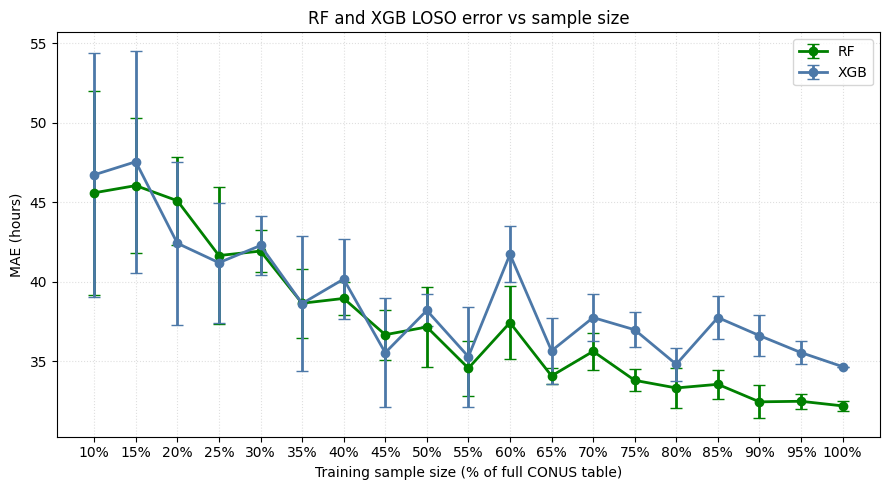

In [ ]:
# --- Plot: RF and XGB LOSO error vs sample size ---

fig, ax = plt.subplots(figsize=(9, 5))
colors = {"RF": "green", "XGB":   "#4c78a8"}

for model_name in ["RF", "XGB"]:
    model_curve = sample_curve_summary[sample_curve_summary["model"] == model_name].sort_values("sample_fraction")
    if model_curve.empty:
        continue

    x = model_curve["sample_percent"]
    ax.errorbar(
        x,
        model_curve["MAE_mean"],
        yerr=model_curve["MAE_sd"],
        marker="o",
        linewidth=2,
        capsize=4,
        color=colors.get(model_name),
        label=model_name,
    )

ax.set_xlabel("Training sample size (% of full CONUS table)")
ax.set_ylabel("MAE (hours)")
ax.set_title("RF and XGB LOSO error vs sample size")
ax.set_xticks(sample_curve_summary["sample_percent"].drop_duplicates().sort_values())
ax.set_xticklabels([f"{int(v)}%" for v in sample_curve_summary["sample_percent"].drop_duplicates().sort_values()])
ax.grid(True, linestyle=":", alpha=0.4)
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "conus_v2_rf_xgb_loso_error_vs_sample_size.png", dpi=200, bbox_inches="tight")
plt.show()


## Random 5-fold CV comparison

This section evaluates the same four model classes using random shuffled 5-fold CV instead of LOSO. Models are still trained on `log1p(t90)`, and all reported metrics are computed after back-transforming predictions to hours. This is less strict than LOSO because counties from the same storm can appear in both train and test folds.


In [ ]:
# --- Random shuffled 5-fold CV: Mean, MLR, RF, XGB ---

from sklearn.model_selection import KFold

RANDOM_KFOLD_SPLITS = 5
random_kfold = KFold(n_splits=RANDOM_KFOLD_SPLITS, shuffle=True, random_state=RANDOM_STATE)

X_random_cv = event_df[available_pre_event].copy().reset_index(drop=True)
y_random_cv = event_df["t90"].astype(float).reset_index(drop=True)
y_random_cv_log = np.log1p(y_random_cv)


def evaluate_random_kfold_log_model(model, X, y_hours, splitter, model_name="model", feature_set="pre_event"):
    y_log = np.log1p(y_hours.astype(float))
    preds_log = np.full(len(y_hours), np.nan)
    fold_rows = []

    for fold_i, (train_idx, test_idx) in enumerate(splitter.split(X), start=1):
        fitted = clone(model)
        fitted.fit(X.iloc[train_idx], y_log.iloc[train_idx])
        pred_log = fitted.predict(X.iloc[test_idx])
        pred_hours = backtransform_log_predictions(pred_log)
        true_hours = y_hours.iloc[test_idx].to_numpy(dtype=float)
        preds_log[test_idx] = pred_log

        row = {
            "model": model_name,
            "feature_set": feature_set,
            "fold": fold_i,
            "n": len(test_idx),
        }
        row.update(compute_hour_metrics(true_hours, pred_hours))
        fold_rows.append(row)

    preds_hours = backtransform_log_predictions(preds_log)
    global_metrics = compute_hour_metrics(y_hours, preds_hours)
    global_metrics.update({
        "model": model_name,
        "feature_set": feature_set,
        "evaluation": "random_5fold_cv",
        "n": len(y_hours),
    })

    pred_df = event_df.loc[X.index, ["storm", "CountyFIPS", "event_start", "t90"]].copy().reset_index(drop=True)
    pred_df["model"] = model_name
    pred_df["feature_set"] = feature_set
    pred_df["evaluation"] = "random_5fold_cv"
    pred_df["pred_log"] = preds_log
    pred_df["pred_hours"] = preds_hours
    pred_df["abs_error_hours"] = np.abs(pred_df["t90"] - pred_df["pred_hours"])

    return pred_df, pd.DataFrame(fold_rows), global_metrics


random_cv_models = {
    "Mean": make_mean_model(available_pre_event),
    "MLR": make_mlr_model(available_pre_event),
}

if ("pre_event", "RF") in best_params:
    random_cv_models["RF"] = make_rf_model(available_pre_event, best_params[("pre_event", "RF")])
else:
    print("Skipping RF random 5-fold CV: run main RF tuning first so best_params is available.")

if HAS_XGBOOST and ("pre_event", "XGB") in best_params:
    random_cv_models["XGB"] = make_xgb_model(available_pre_event, best_params[("pre_event", "XGB")])
elif HAS_XGBOOST:
    print("Skipping XGB random 5-fold CV: run main XGB tuning first so best_params is available.")
else:
    print("Skipping XGB random 5-fold CV because xgboost is not installed.")

random_cv_metrics = []
random_cv_predictions = []
random_cv_folds = []

for model_name, model in random_cv_models.items():
    pred_df, fold_df, metrics = evaluate_random_kfold_log_model(
        model,
        X_random_cv,
        y_random_cv,
        random_kfold,
        model_name=model_name,
        feature_set="pre_event",
    )
    random_cv_metrics.append(metrics)
    random_cv_predictions.append(pred_df)
    random_cv_folds.append(fold_df)
    print(f"{model_name}: MAE={metrics['MAE_hours']:.2f} h, RMSE={metrics['RMSE_hours']:.2f} h, R?={metrics['R2_hours']:.3f}")

random_cv_summary = pd.DataFrame(random_cv_metrics).sort_values("MAE_hours").reset_index(drop=True)
random_cv_predictions_df = pd.concat(random_cv_predictions, ignore_index=True) if random_cv_predictions else pd.DataFrame()
random_cv_folds_df = pd.concat(random_cv_folds, ignore_index=True) if random_cv_folds else pd.DataFrame()

random_cv_summary


Mean: MAE=66.03 h, RMSE=131.32 h, R?=-0.091
MLR: MAE=49.04 h, RMSE=98.70 h, R?=0.384
RF: MAE=25.83 h, RMSE=53.40 h, R?=0.820
XGB: MAE=25.49 h, RMSE=51.10 h, R?=0.835


,MAE_hours,RMSE_hours,R2_hours,median_AE_hours,nMAE_vs_mean_t90,nMAE_vs_median_t90,model,feature_set,evaluation,n
0,25.485047,51.097789,0.834825,12.644262,0.262401,0.454124,XGB,pre_event,random_5fold_cv,913
1,25.831026,53.399146,0.819611,12.733240,0.265963,0.460289,RF,pre_event,random_5fold_cv,913
2,49.041497,98.700100,0.383723,20.371101,0.504945,0.873882,MLR,pre_event,random_5fold_cv,913
3,66.032612,131.322161,-0.090981,31.346737,0.679890,1.176650,Mean,pre_event,random_5fold_cv,913


Saved random 5-fold CV files:
C:\Users\teaching\Downloads\outage-recovery-forecasting\data_transients\conus_v2_log_target_random_5fold_results_summary.csv
C:\Users\teaching\Downloads\outage-recovery-forecasting\data_transients\conus_v2_log_target_random_5fold_predictions.csv
C:\Users\teaching\Downloads\outage-recovery-forecasting\data_transients\conus_v2_log_target_random_5fold_folds.csv


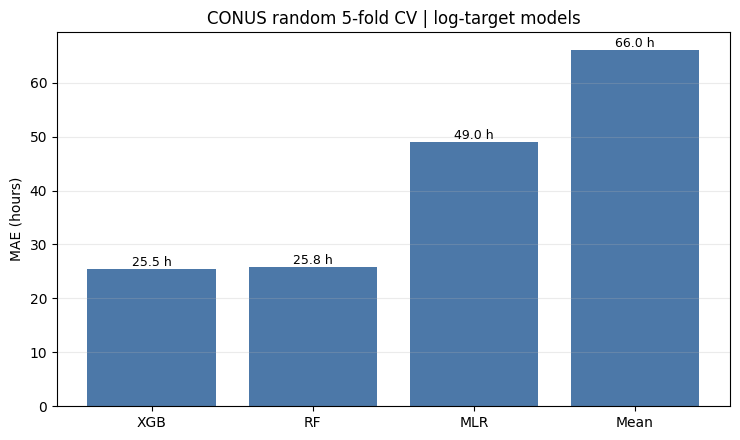

,MAE_hours,RMSE_hours,R2_hours,median_AE_hours,nMAE_vs_mean_t90,nMAE_vs_median_t90,model,feature_set,evaluation,n
0,25.485047,51.097789,0.834825,12.644262,0.262401,0.454124,XGB,pre_event,random_5fold_cv,913
1,25.831026,53.399146,0.819611,12.733240,0.265963,0.460289,RF,pre_event,random_5fold_cv,913
2,49.041497,98.700100,0.383723,20.371101,0.504945,0.873882,MLR,pre_event,random_5fold_cv,913
3,66.032612,131.322161,-0.090981,31.346737,0.679890,1.176650,Mean,pre_event,random_5fold_cv,913


In [ ]:
# --- Save and plot random 5-fold CV results ---

random_cv_summary_path = DATA_DIR / "conus_v2_log_target_random_5fold_results_summary.csv"
random_cv_pred_path = DATA_DIR / "conus_v2_log_target_random_5fold_predictions.csv"
random_cv_fold_path = DATA_DIR / "conus_v2_log_target_random_5fold_folds.csv"

random_cv_summary.to_csv(random_cv_summary_path, index=False)
random_cv_predictions_df.to_csv(random_cv_pred_path, index=False)
random_cv_folds_df.to_csv(random_cv_fold_path, index=False)

print("Saved random 5-fold CV files:")
print(random_cv_summary_path)
print(random_cv_pred_path)
print(random_cv_fold_path)

fig, ax = plt.subplots(figsize=(7.5, 4.5))
plot_df = random_cv_summary.sort_values("MAE_hours")
ax.bar(plot_df["model"], plot_df["MAE_hours"], color="#4c78a8")
ax.set_ylabel("MAE (hours)")
ax.set_title("CONUS random 5-fold CV | log-target models")
ax.grid(axis="y", alpha=0.25)
for i, value in enumerate(plot_df["MAE_hours"]):
    ax.text(i, value, f"{value:.1f} h", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / "conus_v2_random_5fold_model_comparison_mae_hours.png", dpi=200, bbox_inches="tight")
plt.show()

random_cv_summary


CONUS random 5-fold CV: Mean metrics:
MAE:  66.033 hours
RMSE: 131.322 hours
R^2:  -0.091
nMAE / range: 0.097


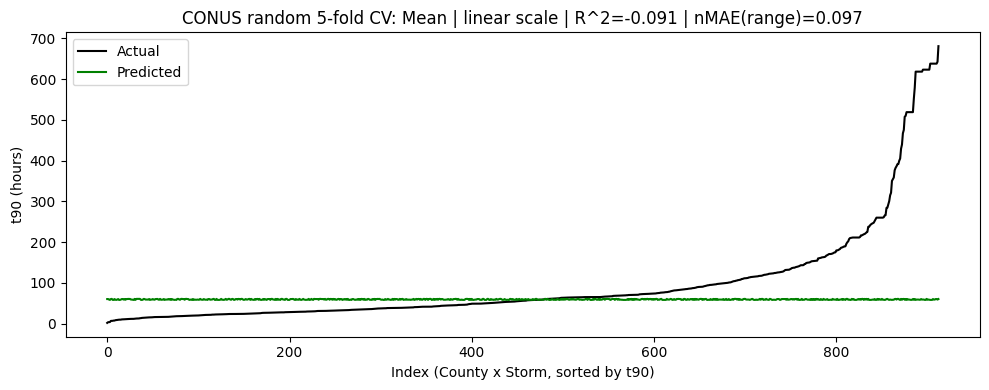

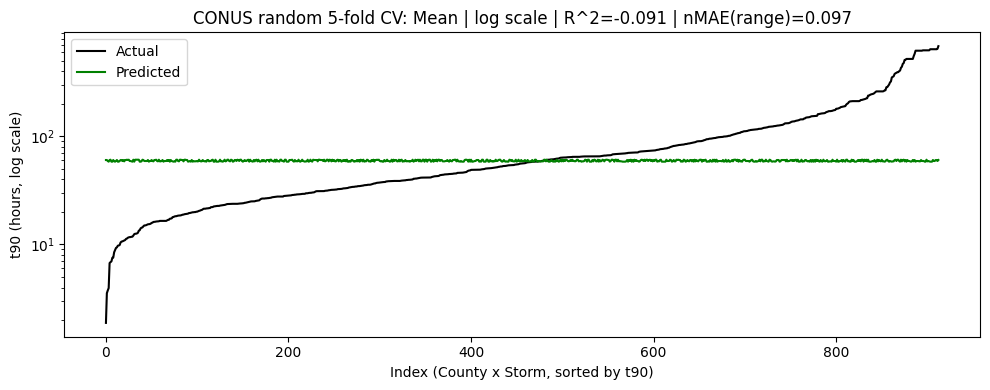

CONUS random 5-fold CV: MLR metrics:
MAE:  49.041 hours
RMSE: 98.700 hours
R^2:  0.384
nMAE / range: 0.072


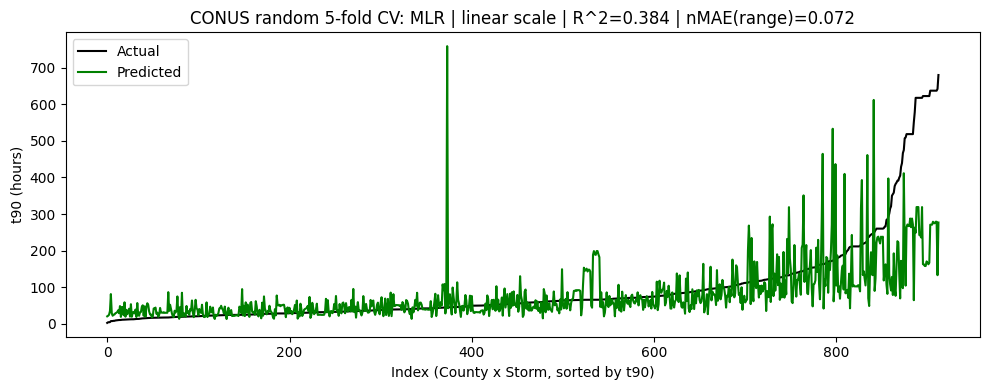

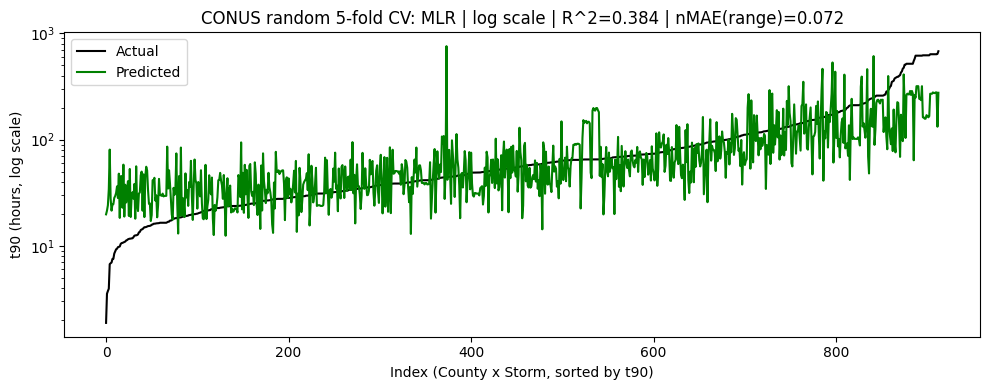

CONUS random 5-fold CV: RF metrics:
MAE:  25.831 hours
RMSE: 53.399 hours
R^2:  0.820
nMAE / range: 0.038


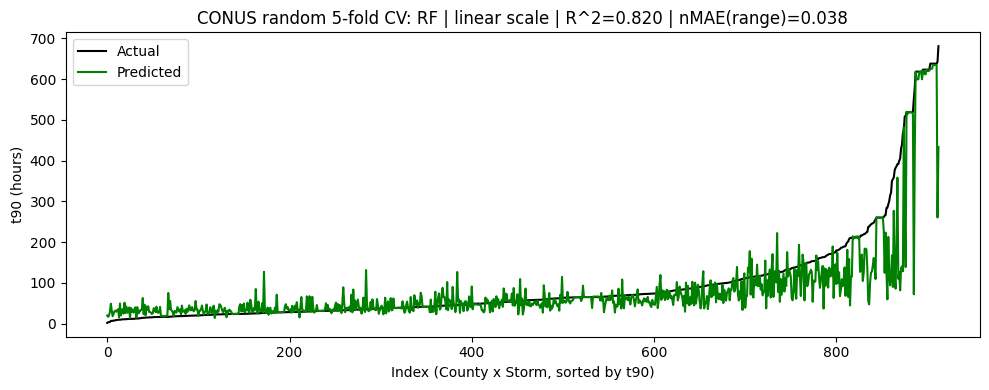

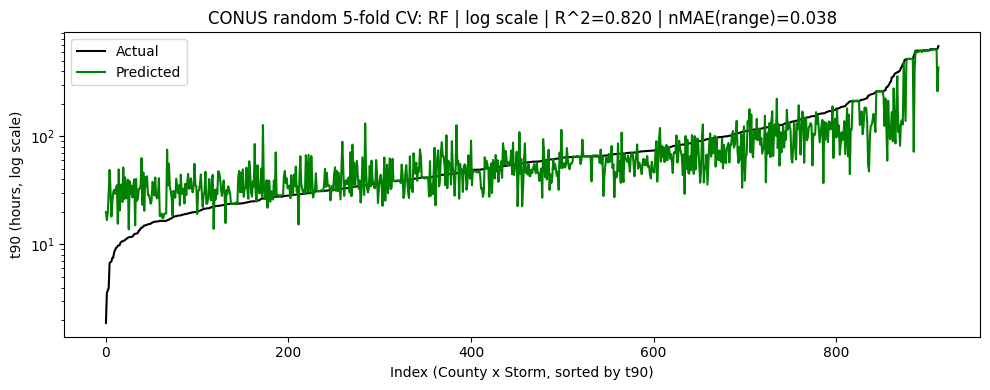

CONUS random 5-fold CV: XGB metrics:
MAE:  25.485 hours
RMSE: 51.098 hours
R^2:  0.835
nMAE / range: 0.038


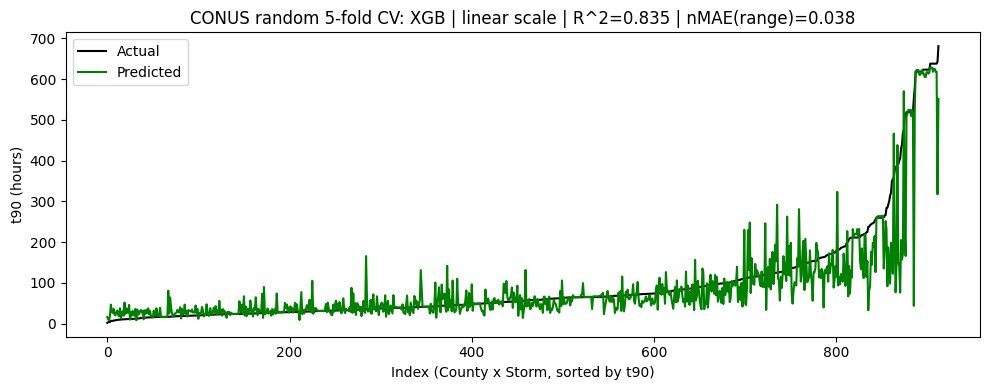

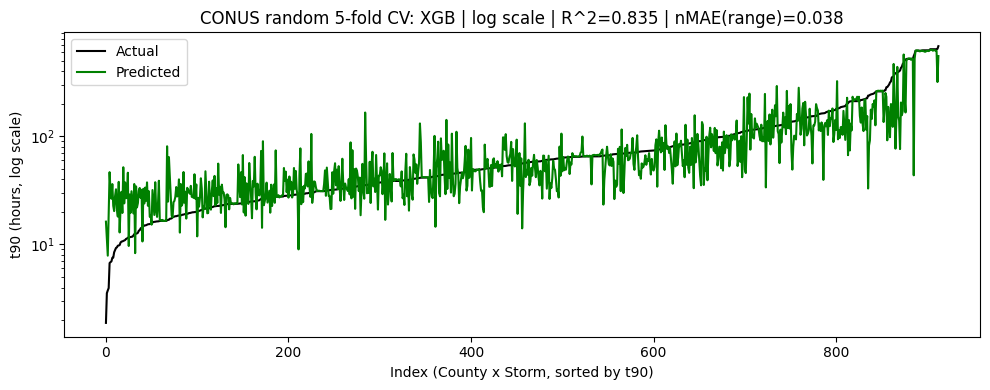

In [ ]:
# --- Random 5-fold ranked plots for all available model classes ---

for model_name in ["Mean", "MLR", "RF", "XGB"]:
    if random_cv_predictions_df.empty or model_name not in set(random_cv_predictions_df["model"]):
        print(f"Skipping {model_name}: no random 5-fold predictions found.")
        continue

    pred_df_model = random_cv_predictions_df[random_cv_predictions_df["model"] == model_name].copy()
    report_ranked_predictions_v2(
        pred_df_model,
        title=f"CONUS random 5-fold CV: {model_name}",
        save_prefix=f"conus_v2_random_5fold_{model_name.lower()}",
    )


## LOSO vs random 5-fold CV comparison

This chart compares the stricter leave-one-storm-out evaluation against random shuffled 5-fold CV for the four model classes.


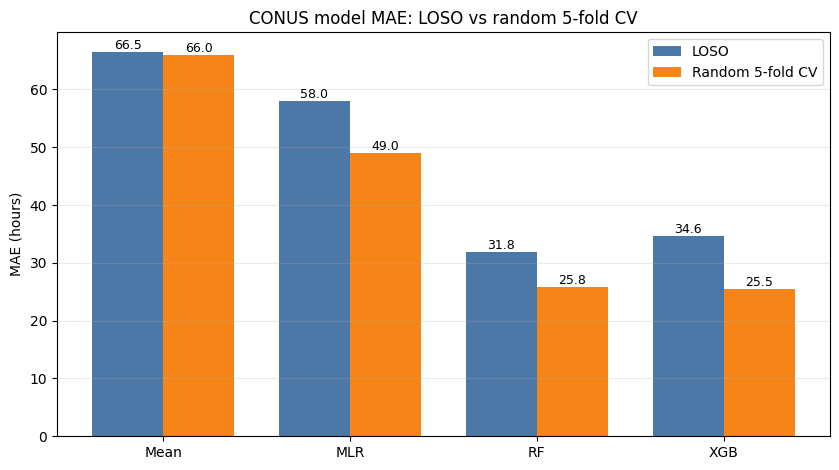

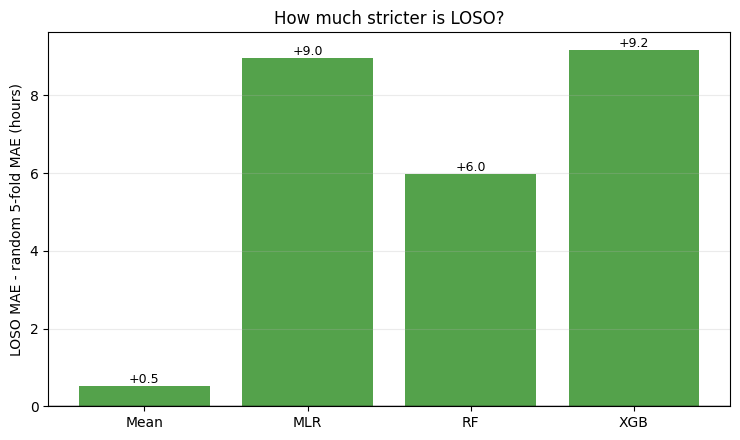

,model,LOSO_MAE_hours,Random_5fold_MAE_hours,MAE_difference_LOSO_minus_5fold,MAE_difference_pct
0,Mean,66.544857,66.032612,0.512244,0.769773
1,MLR,58.005067,49.041497,8.963569,15.453080
2,RF,31.803428,25.831026,5.972402,18.779115
3,XGB,34.648178,25.485047,9.163131,26.446214


In [ ]:
# --- Bar chart: LOSO vs random 5-fold CV MAE for all four model classes ---

if "results_summary" not in globals():
    raise RuntimeError("results_summary is missing. Run the main LOSO modelling section first.")
if "random_cv_summary" not in globals():
    raise RuntimeError("random_cv_summary is missing. Run the random 5-fold CV section first.")

loso_mae = (
    results_summary[results_summary["feature_set"] == "pre_event"]
    [["model", "MAE_hours"]]
    .rename(columns={"MAE_hours": "LOSO_MAE_hours"})
)

random_mae = (
    random_cv_summary[["model", "MAE_hours"]]
    .rename(columns={"MAE_hours": "Random_5fold_MAE_hours"})
)

cv_compare = loso_mae.merge(random_mae, on="model", how="inner")
cv_compare["MAE_difference_LOSO_minus_5fold"] = cv_compare["LOSO_MAE_hours"] - cv_compare["Random_5fold_MAE_hours"]
cv_compare["MAE_difference_pct"] = 100 * cv_compare["MAE_difference_LOSO_minus_5fold"] / cv_compare["LOSO_MAE_hours"]

model_order = [m for m in ["Mean", "MLR", "RF", "XGB"] if m in set(cv_compare["model"])]
cv_compare["model"] = pd.Categorical(cv_compare["model"], categories=model_order, ordered=True)
cv_compare = cv_compare.sort_values("model").reset_index(drop=True)

x = np.arange(len(cv_compare))
width = 0.38

fig, ax = plt.subplots(figsize=(8.5, 4.8))
ax.bar(x - width / 2, cv_compare["LOSO_MAE_hours"], width, label="LOSO", color="#4c78a8")
ax.bar(x + width / 2, cv_compare["Random_5fold_MAE_hours"], width, label="Random 5-fold CV", color="#f58518")

ax.set_xticks(x)
ax.set_xticklabels(cv_compare["model"].astype(str))
ax.set_ylabel("MAE (hours)")
ax.set_title("CONUS model MAE: LOSO vs random 5-fold CV")
ax.grid(axis="y", alpha=0.25)
ax.legend()

for i, row in cv_compare.iterrows():
    ax.text(i - width / 2, row["LOSO_MAE_hours"], f"{row['LOSO_MAE_hours']:.1f}", ha="center", va="bottom", fontsize=9)
    ax.text(i + width / 2, row["Random_5fold_MAE_hours"], f"{row['Random_5fold_MAE_hours']:.1f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig(FIG_DIR / "conus_v2_loso_vs_random_5fold_mae_bar.png", dpi=200, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(7.5, 4.5))
colors = np.where(cv_compare["MAE_difference_LOSO_minus_5fold"] >= 0, "#54a24b", "#e45756")
ax.bar(cv_compare["model"].astype(str), cv_compare["MAE_difference_LOSO_minus_5fold"], color=colors)
ax.axhline(0, color="black", lw=1)
ax.set_ylabel("LOSO MAE - random 5-fold MAE (hours)")
ax.set_title("How much stricter is LOSO?")
ax.grid(axis="y", alpha=0.25)
for i, value in enumerate(cv_compare["MAE_difference_LOSO_minus_5fold"]):
    va = "bottom" if value >= 0 else "top"
    ax.text(i, value, f"{value:+.1f}", ha="center", va=va, fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / "conus_v2_loso_minus_random_5fold_mae_difference.png", dpi=200, bbox_inches="tight")
plt.show()

cv_compare
